# Chain-of-Thought vs Extended Thinking
### A 2-step prompt chain, measured in tokens

**The scenario:** an agentic-style task where Call 2 must build on Call 1's reasoning.

> A logistics planner is deciding whether a shipment qualifies for express handling.
> Call 1 analyzes the shipment (weight, distance, deadline) and reasons through the decision.
> Call 2 takes that reasoning and produces the final structured recommendation.

We run this **same problem statement** through two branches:

| Branch | Reasoning mechanism | How Call 2 gets Call 1's reasoning |
|---|---|---|
| **A. Plain CoT** | `"Think step by step"` in the prompt, no `thinking` param | You manually copy the **entire text response** back into Call 2's message history |
| **B. Extended Thinking** | `thinking: {type: "adaptive"}` | You pass the **structured `thinking` block(s)** back verbatim; the API manages/prunes what's billed |

### What this notebook will (and won't) prove

- ✅ It will show the **mechanical difference**: CoT reasoning is plain text you own and must re-paste; extended-thinking reasoning is an opaque block the API validates and manages for you.
- ✅ It will show real `usage` token counts for both branches, side by side.
- ✅ It will show the API **rejecting** a tampered thinking block — proof these blocks are integrity-checked, not just cosmetic.
- ⚠️ It will **not** show `redacted_thinking` as a "lighter/compressed" version of reasoning. Redaction is an *encrypted* safety fallback that appears occasionally when Claude's internal reasoning gets flagged — it's the same reasoning, encrypted, not a smaller one. You can't reliably force it (Anthropic ships a magic test string for that, used below only as a demo).
- ⚠️ Over just 2 calls, raw token savings from extended thinking may be modest — the API's automatic pruning of old thinking blocks is a benefit that compounds over **longer** multi-turn conversations, not necessarily this single round trip. The notebook prints the numbers so you can see this honestly rather than assuming a dramatic gap.
- ✅ It will show **cost in USD** (not just raw token counts) and **round-trip latency** side by side, since thinking tokens bill as output and reasoning-before-answering adds wall-clock time — the two branches may trade off differently on each axis.


## 0. Setup

In [1]:
%pip install -q anthropic matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import copy
import time
from dotenv import load_dotenv
from anthropic import Anthropic

# Reads a .env file in the current working directory (or pass
# dotenv_path="/absolute/path/to/.env" if it lives elsewhere) and loads its
# key=value pairs into os.environ. Your .env should contain a line like:
#   ANTHROPIC_API_KEY=sk-ant-api03-...
load_dotenv()

api_key = os.environ.get("ANTHROPIC_API_KEY")
if not api_key:
    raise ValueError(
        "ANTHROPIC_API_KEY not found. Check that a .env file exists in this "
        "notebook's directory and contains ANTHROPIC_API_KEY=<your key>."
    )

client = Anthropic(api_key=api_key)

MODEL = "claude-sonnet-4-6"
MAX_TOKENS = 2048

PROBLEM_STATEMENT = (
    "A shipment weighs 42kg, needs to travel 1,850km, and the customer's "
    "deadline is 36 hours from now. Our express carrier can guarantee "
    "delivery in 30 hours for shipments under 50kg travelling under 2,000km, "
    "but express slots cost 3x standard shipping. Standard shipping takes "
    "48 hours regardless of weight or distance under 2,500km. "
    "Decide whether this shipment needs express handling, and justify it."
)

print("Problem statement loaded. Model:", MODEL)

Problem statement loaded. Model: claude-sonnet-4-6


## Part 1 — Branch A: Plain Chain-of-Thought (simple problem)

No `thinking` param. We just ask Claude to reason step by step in its normal text output.
The **entire text** (reasoning + answer) is regular output content — there's no separation
between "scratchpad" and "final answer" as far as the API is concerned.

In [7]:
_t0 = time.time()
cot_call_1 = client.messages.create(
    model=MODEL,
    max_tokens=MAX_TOKENS,
    messages=[
        {
            "role": "user",
            "content": (
                "Think step by step and show your full reasoning before you "
                "answer.\n\n" + PROBLEM_STATEMENT
            ),
        }
    ],
)
cot_call_1_latency = time.time() - _t0

cot_call_1_text = "".join(block.text for block in cot_call_1.content if block.type == "text")

print("--- Call 1 response (truncated) ---")
print(cot_call_1_text[:600], "...\n")
print("Call 1 usage:", cot_call_1.usage)
print(f"Call 1 latency: {cot_call_1_latency:.2f}s")

--- Call 1 response (truncated) ---
## Step-by-Step Reasoning

### Step 1: Establish the Customer Requirement

The customer's deadline is **36 hours from now**. This is the hard constraint everything else must be measured against.

---

### Step 2: Evaluate Standard Shipping

- Standard shipping takes **48 hours** for shipments under 2,500km and under any relevant weight threshold.
- This shipment: 42kg, 1,850km — qualifies for standard shipping.
- **48 hours > 36 hours deadline.**
- ❌ Standard shipping **misses the deadline by 12 hours.** It is not viable.

---

### Step 3: Evaluate Express Shipping

Express carrier conditions  ...

Call 1 usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=121, output_tokens=641, output_tokens_details=None, server_tool_use=None, service_tier='standard')
Call 1 latency: 15.91s


In [11]:
# Call 2: we MUST manually paste the entire Call 1 text back in to preserve
# continuity. This is the "increased token cost"  —
# it's just normal message history, but that history contains the full
# reasoning transcript, verbatim, every time.
cot_messages = [
    {"role": "user", "content": PROBLEM_STATEMENT},
    {"role": "assistant", "content": cot_call_1_text},
    {
        "role": "user",
        "content": (
            "Based on your analysis above, give me ONLY the final decision "
            "in this exact format: 'Decision: <EXPRESS|STANDARD>. Reason: <one sentence>.'"
        ),
    },
]

_t0 = time.time()
cot_call_2 = client.messages.create(
    model=MODEL,
    max_tokens=300,
    messages=cot_messages,
)
cot_call_2_latency = time.time() - _t0

cot_call_2_text = "".join(block.text for block in cot_call_2.content if block.type == "text")
print("--- Call 2 final answer ---")
print(cot_call_2_text)
print("\nCall 2 usage:", cot_call_2.usage)
print(f"Call 2 latency: {cot_call_2_latency:.2f}s")

--- Call 2 final answer ---
Decision: EXPRESS. Reason: Standard shipping's 48-hour transit time misses the 36-hour deadline by 12 hours, making express the only viable option at 30 hours guaranteed delivery.

Call 2 usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=788, output_tokens=47, output_tokens_details=None, server_tool_use=None, service_tier='standard')
Call 2 latency: 1.72s


## Part 1 — Branch B: Extended Thinking (adaptive, simple problem)

Same problem statement. `thinking.type = "adaptive"` lets Claude decide how much to think.
The reasoning comes back as a **structured `thinking` block** (with an opaque `signature`),
separate from the `text` block that holds the visible answer.

In [ ]:
_t0 = time.time()
ext_call_1 = client.messages.create(
    model=MODEL,
    max_tokens=MAX_TOKENS,
    thinking={"type": "adaptive"},
    output_config={"effort": "high"},
    messages=[{"role": "user", "content": PROBLEM_STATEMENT}],
)
ext_call_1_latency = time.time() - _t0

#print(ext_call_1.content)

thinking_blocks = [b for b in ext_call_1.content if b.type in ("thinking", "redacted_thinking")]
text_blocks = [b for b in ext_call_1.content if b.type == "text"]

print(f"Content blocks returned: {[b.type for b in ext_call_1.content]}\n")
if thinking_blocks and thinking_blocks[0].type == "thinking":
    print("--- Thinking block (truncated) ---")
    print(thinking_blocks[0].thinking[:500], "...\n")
print("--- Visible answer ---")
print("".join(b.text for b in text_blocks)[:500])
print("\nCall 1 usage:", ext_call_1.usage)
print(f"Call 1 latency: {ext_call_1_latency:.2f}s")

[ThinkingBlock(signature='ErkKCpIBCBIYAipAHd3KPO1o0aRalDqSb8g5YC2Mc75+SbfWkO9sDgEnoQn7v8B5mFjphh9GacgigCZwF9g3+BdQ3Suk6Sg5qvpioTIRY2xhdWRlLXNvbm5ldC00LTY4AEIIdGhpbmtpbmdaJGZmOWQzMGQzLTY1ZDktNDZhNi04MDU5LTBlMWNhZDU0NTNiOKgB/Jzl1QYSDOcO7ST4az94GsaO6hoMNNKzaacS0SVJoPu0IjBecCJsIxhkL8dg4eNDePfdke+YUlFNE+S7ards/DYMcIbNEaheEmYS0oYwZFgDYb8q0wiFXWMg1yCsvkII7mdbNb+EOtcjV276cp5N+tyXmiOvnUJwSHp574q86r3D01PhzB/P77ZZfTWS46uyJspGtdwGi4cD0JAc5rOgc83blAFVXPEVxTZsolkkau7uUgiEFSIE8AnCYvGMmi+toeQrsOfh5mp/N0aEHsricz0ig8ILHS1Dnm+DZZrWWb9TnGzZLcUxfQym/3xSiT/oWEehXOBqkoAMWvJ6kK4vr+mEv0gRD0XyppjIoP4QOClggdK9MFcvPdIx3OdagB0FqrNiH1ae/GQkdotqvX9d8FtDDSTUDUfG1FgvZOfUtQIOSwfZqubmLT7ZANXGqn/EVS1L1orTijbx7tjBY1nJLB9RyCp7K5Er4UKmcNnWJX4lDCOuXcht3i+oYqI02tHXF67orI9P+Sk//pmWTzEo9qTHVg/Wh93oef38cptVMLqxHYpYDcwijSRk4mIxxeNV+cb0vLdNZzUMoz48e3vodzXJ49sVnwwkNGzRwFS2Km2eildWwH6Zz/aS5tDr4fGu2jDV5lByTO+sYlewOWKFO6BcxPSOG0Wb6Izul3LN29UIqeMuWd4YFAlxAcqQpD09nVtFgEndsgWaPo3gkqy/goiSpuqRtDuLdcUwg3lUmEf5qPlii5S/NbD9fYiIA1P4dHyUAkvZkU

In [9]:
# Call 2: pass the ENTIRE assistant message back verbatim — thinking blocks
# included, unmodified, in the exact order received. This is a hard
# requirement: the API rejects reordered/edited/partially-dropped thinking
# blocks with a 400 error (demonstrated further down).
#
# We don't hand-copy any text here — we just echo the SDK's own message
# object back. The API internally decides which thinking blocks it still
# needs and bills input tokens only for those it actually shows to Claude.
ext_messages = [
    {"role": "user", "content": PROBLEM_STATEMENT},
    {"role": "assistant", "content": ext_call_1.content},
    {
        "role": "user",
        "content": (
            "Based on your analysis above, give me ONLY the final decision "
            "in this exact format: 'Decision: <EXPRESS|STANDARD>. Reason: <one sentence>.'"
        ),
    },
]

_t0 = time.time()
ext_call_2 = client.messages.create(
    model=MODEL,
    max_tokens=300,
    thinking={"type": "adaptive"},
    output_config={"effort": "high"},
    messages=ext_messages,
)
ext_call_2_latency = time.time() - _t0

ext_call_2_text = "".join(b.text for b in ext_call_2.content if b.type == "text")
print("--- Call 2 final answer ---")
print(ext_call_2_text)
print("\nCall 2 usage:", ext_call_2.usage)
print(f"Call 2 latency: {ext_call_2_latency:.2f}s")

--- Call 2 final answer ---
Decision: EXPRESS. Reason: Standard shipping (48 hours) misses the 36-hour deadline, making express (30 hours) the only viable option.

Call 2 usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=921, output_tokens=38, output_tokens_details=OutputTokensDetails(thinking_tokens=0), server_tool_use=None, service_tier='standard')
Call 2 latency: 1.51s


## Side-by-side token comparison

In [12]:
def usage_dict(u):
    return {
        "input_tokens": u.input_tokens,
        "output_tokens": u.output_tokens,
        "cache_read_input_tokens": getattr(u, "cache_read_input_tokens", 0) or 0,
    }

results = {
    "CoT - Call 1": usage_dict(cot_call_1.usage),
    "CoT - Call 2": usage_dict(cot_call_2.usage),
    "ExtThinking - Call 1": usage_dict(ext_call_1.usage),
    "ExtThinking - Call 2": usage_dict(ext_call_2.usage),
}

print(f"{'Call':<24}{'input_tokens':>14}{'output_tokens':>15}")
print("-" * 53)
for name, u in results.items():
    print(f"{name:<24}{u['input_tokens']:>14}{u['output_tokens']:>15}")

cot_total_input = results["CoT - Call 1"]["input_tokens"] + results["CoT - Call 2"]["input_tokens"]
ext_total_input = results["ExtThinking - Call 1"]["input_tokens"] + results["ExtThinking - Call 2"]["input_tokens"]

print("\nTotal input tokens across both calls:")
print(f"  Plain CoT:         {cot_total_input}")
print(f"  Extended Thinking: {ext_total_input}")
print(
    f"\nNote: this is a 2-call snapshot. The gap widens as the conversation "
    f"grows longer, since the API keeps pruning old thinking blocks from the "
    f"billed input on Claude's side, while a plain-text CoT transcript just "
    f"keeps growing turn over turn unless YOU manually trim it."
)

Call                      input_tokens  output_tokens
-----------------------------------------------------
CoT - Call 1                       121            641
CoT - Call 2                       788             47
ExtThinking - Call 1               107            774
ExtThinking - Call 2               921             38

Total input tokens across both calls:
  Plain CoT:         909
  Extended Thinking: 1028

Note: this is a 2-call snapshot. The gap widens as the conversation grows longer, since the API keeps pruning old thinking blocks from the billed input on Claude's side, while a plain-text CoT transcript just keeps growing turn over turn unless YOU manually trim it.


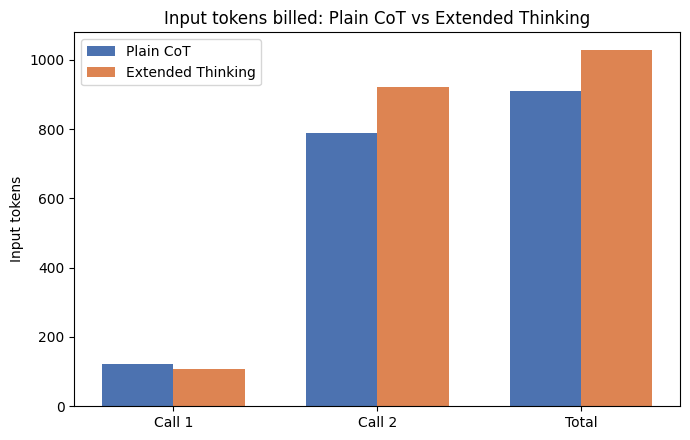

In [13]:
import matplotlib.pyplot as plt

labels = ["Call 1", "Call 2", "Total"]
cot_vals = [
    results["CoT - Call 1"]["input_tokens"],
    results["CoT - Call 2"]["input_tokens"],
    cot_total_input,
]
ext_vals = [
    results["ExtThinking - Call 1"]["input_tokens"],
    results["ExtThinking - Call 2"]["input_tokens"],
    ext_total_input,
]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="white")
ax.set_facecolor("white")
ax.bar([i - width / 2 for i in x], cot_vals, width, label="Plain CoT", color="#4C72B0")
ax.bar([i + width / 2 for i in x], ext_vals, width, label="Extended Thinking", color="#DD8452")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, color="black")
ax.set_ylabel("Input tokens", color="black")
ax.set_title("Input tokens billed: Plain CoT vs Extended Thinking", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_color("black")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# --- Pricing config: verify against https://platform.claude.com/docs/en/about-claude/models/overview ---
PRICE_INPUT_PER_MTOK = 3.00    # $ per 1M input tokens  (claude-sonnet-4-6)
PRICE_OUTPUT_PER_MTOK = 15.00  # $ per 1M output tokens (claude-sonnet-4-6, includes thinking tokens)
# Cached input reads are billed at a fraction of normal input price (commonly ~10%).
# Check the docs for the exact cache-read multiplier on your model before relying on this.
PRICE_CACHE_READ_PER_MTOK = PRICE_INPUT_PER_MTOK * 0.1


def call_cost_usd(usage) -> float:
    """Compute the USD cost of a single API call from its `usage` object.

    - input_tokens and output_tokens are always present.
    - output_tokens already INCLUDES thinking tokens for extended-thinking
      calls — Anthropic bills thinking as output, so no separate line item
      is needed here.
    - cache_read_input_tokens (if any) is billed at the discounted rate
      instead of full input price.
    """
    cache_read = getattr(usage, "cache_read_input_tokens", 0) or 0
    regular_input = usage.input_tokens  # SDK already excludes cache-read tokens from this field
    cost = (
        regular_input / 1_000_000 * PRICE_INPUT_PER_MTOK
        + cache_read / 1_000_000 * PRICE_CACHE_READ_PER_MTOK
        + usage.output_tokens / 1_000_000 * PRICE_OUTPUT_PER_MTOK
    )
    return cost


cost_breakdown = {
    "CoT - Call 1": call_cost_usd(cot_call_1.usage),
    "CoT - Call 2": call_cost_usd(cot_call_2.usage),
    "ExtThinking - Call 1": call_cost_usd(ext_call_1.usage),
    "ExtThinking - Call 2": call_cost_usd(ext_call_2.usage),
}

print(f"{'Call':<24}{'Cost (USD)':>14}")
print("-" * 38)
for name, cost in cost_breakdown.items():
    print(f"{name:<24}{cost:>14.6f}")

cot_total_cost = cost_breakdown["CoT - Call 1"] + cost_breakdown["CoT - Call 2"]
ext_total_cost = cost_breakdown["ExtThinking - Call 1"] + cost_breakdown["ExtThinking - Call 2"]

print("\nTotal cost across both calls:")
print(f"  Plain CoT:         ${cot_total_cost:.6f}")
print(f"  Extended Thinking: ${ext_total_cost:.6f}")

cheaper = "Plain CoT" if cot_total_cost < ext_total_cost else "Extended Thinking"
diff_pct = abs(cot_total_cost - ext_total_cost) / max(cot_total_cost, ext_total_cost) * 100
print(f"\n→ {cheaper} was cheaper on this run, by {diff_pct:.1f}%.")
print(
    "Note: a single 2-call round trip is a small sample — run this a few times "
    "and average, since thinking length varies per call. The cost gap is expected "
    "to widen in extended thinking's favor as the conversation grows longer "
    "(more turns / tool calls), not necessarily on a single short exchange."
)

Call                        Cost (USD)
--------------------------------------
CoT - Call 1                  0.009978
CoT - Call 2                  0.003069
ExtThinking - Call 1          0.011931
ExtThinking - Call 2          0.003333

Total cost across both calls:
  Plain CoT:         $0.013047
  Extended Thinking: $0.015264

→ Plain CoT was cheaper on this run, by 14.5%.
Note: a single 2-call round trip is a small sample — run this a few times and average, since thinking length varies per call. The cost gap is expected to widen in extended thinking's favor as the conversation grows longer (more turns / tool calls), not necessarily on a single short exchange.


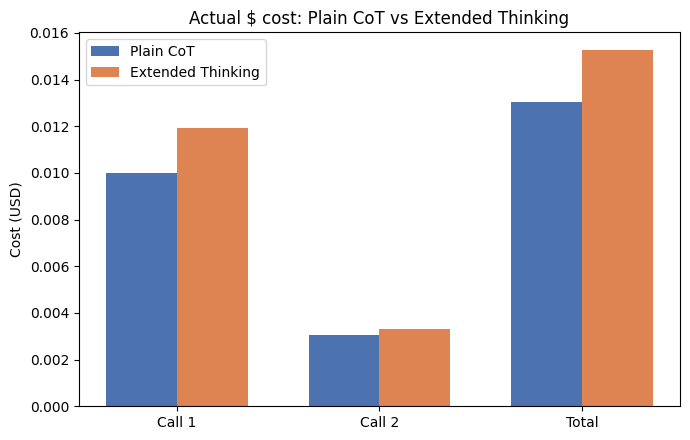

In [21]:
labels_cost = ["Call 1", "Call 2", "Total"]
cot_cost_vals = [
    cost_breakdown["CoT - Call 1"],
    cost_breakdown["CoT - Call 2"],
    cot_total_cost,
]
ext_cost_vals = [
    cost_breakdown["ExtThinking - Call 1"],
    cost_breakdown["ExtThinking - Call 2"],
    ext_total_cost,
]

x2 = range(len(labels_cost))
width2 = 0.35

fig2, ax2 = plt.subplots(figsize=(7, 4.5), facecolor="white")
ax2.set_facecolor("white")
ax2.bar([i - width2 / 2 for i in x2], cot_cost_vals, width2, label="Plain CoT", color="#4C72B0")
ax2.bar([i + width2 / 2 for i in x2], ext_cost_vals, width2, label="Extended Thinking", color="#DD8452")

ax2.set_xticks(list(x2))
ax2.set_xticklabels(labels_cost, color="black")
ax2.set_ylabel("Cost (USD)", color="black")
ax2.set_title("Actual $ cost: Plain CoT vs Extended Thinking", color="black")
ax2.tick_params(colors="black")
for spine in ax2.spines.values():
    spine.set_color("black")
ax2.legend()
plt.tight_layout()
plt.show()

### Want a more realistic signal? Simulate a longer conversation

A 2-call comparison is a weak sample — real agentic workflows run 5, 10, or 20+
turns. The cell below wraps both branches in a loop that keeps extending the
same conversation with a new follow-up question each round, so you can watch
the **cumulative cost curves diverge** as turn count grows. This is the
strongest evidence for "the API's automatic pruning compounds over time" —
worth running before you finalize the blog's numbers.

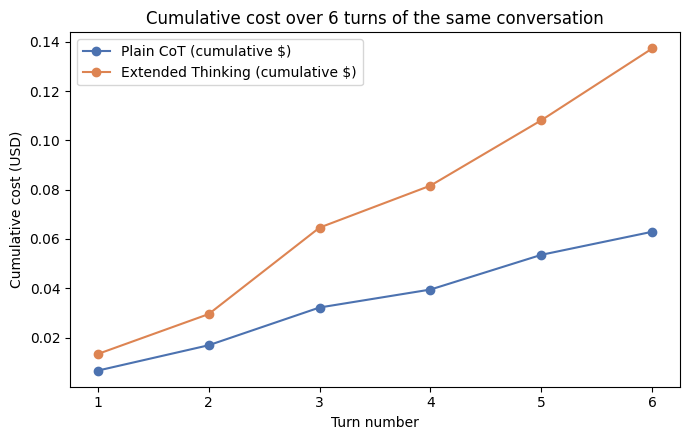

Final cumulative cost after 6 turns:
  Plain CoT:         $0.062907
  Extended Thinking: $0.137265


In [22]:
N_TURNS = 6  # increase for a more dramatic curve; each turn = 1 extra API call per branch

follow_up_questions = [
    "What if the shipment weight increases to 55kg — does your decision change?",
    "What if the deadline were 48 hours instead — does your decision change?",
    "Summarize your reasoning so far in exactly two sentences.",
    "Now assume distance drops to 900km — re-evaluate.",
    "What's the single biggest risk in your recommendation?",
]

# --- Branch A: plain CoT, manually growing the pasted-back transcript ---
cot_running_messages = [{"role": "user", "content": PROBLEM_STATEMENT}]
cot_cumulative_cost = []
running_total = 0.0

resp = client.messages.create(model=MODEL, max_tokens=MAX_TOKENS, messages=cot_running_messages)
resp_text = "".join(b.text for b in resp.content if b.type == "text")
cot_running_messages.append({"role": "assistant", "content": resp_text})
running_total += call_cost_usd(resp.usage)
cot_cumulative_cost.append(running_total)

for i in range(N_TURNS - 1):
    q = follow_up_questions[i % len(follow_up_questions)]
    cot_running_messages.append({"role": "user", "content": q})
    resp = client.messages.create(model=MODEL, max_tokens=MAX_TOKENS, messages=cot_running_messages)
    resp_text = "".join(b.text for b in resp.content if b.type == "text")
    cot_running_messages.append({"role": "assistant", "content": resp_text})
    running_total += call_cost_usd(resp.usage)
    cot_cumulative_cost.append(running_total)

# --- Branch B: extended thinking, echoing SDK content blocks back verbatim ---
ext_running_messages = [{"role": "user", "content": PROBLEM_STATEMENT}]
ext_cumulative_cost = []
running_total = 0.0

resp = client.messages.create(
    model=MODEL, max_tokens=MAX_TOKENS, thinking={"type": "adaptive"},
    output_config={"effort": "high"}, messages=ext_running_messages,
)
ext_running_messages.append({"role": "assistant", "content": resp.content})
running_total += call_cost_usd(resp.usage)
ext_cumulative_cost.append(running_total)

for i in range(N_TURNS - 1):
    q = follow_up_questions[i % len(follow_up_questions)]
    ext_running_messages.append({"role": "user", "content": q})
    resp = client.messages.create(
        model=MODEL, max_tokens=MAX_TOKENS, thinking={"type": "adaptive"},
        output_config={"effort": "high"}, messages=ext_running_messages,
    )
    ext_running_messages.append({"role": "assistant", "content": resp.content})
    running_total += call_cost_usd(resp.usage)
    ext_cumulative_cost.append(running_total)

fig3, ax3 = plt.subplots(figsize=(7, 4.5), facecolor="white")
ax3.set_facecolor("white")
turns = list(range(1, N_TURNS + 1))
ax3.plot(turns, cot_cumulative_cost, marker="o", label="Plain CoT (cumulative $)", color="#4C72B0")
ax3.plot(turns, ext_cumulative_cost, marker="o", label="Extended Thinking (cumulative $)", color="#DD8452")
ax3.set_xlabel("Turn number", color="black")
ax3.set_ylabel("Cumulative cost (USD)", color="black")
ax3.set_title(f"Cumulative cost over {N_TURNS} turns of the same conversation", color="black")
ax3.tick_params(colors="black")
for spine in ax3.spines.values():
    spine.set_color("black")
ax3.legend()
plt.tight_layout()
plt.show()

print(f"Final cumulative cost after {N_TURNS} turns:")
print(f"  Plain CoT:         ${cot_cumulative_cost[-1]:.6f}")
print(f"  Extended Thinking: ${ext_cumulative_cost[-1]:.6f}")

## Latency comparison

Anthropic's own chain-of-thought guidance calls
out that longer reasoning output can impact latency. Extended thinking has the
same effect in the other direction: Claude reasons internally *before* the
first visible token comes back, so time-to-first-response tends to be higher,
even though the total tokens moved may be similar or fewer than a CoT
transcript.

This matters for real product decisions: a cheaper approach that takes 3x
longer to respond may still be the wrong choice for a user-facing chat UI,
even if it wins on cost. This is measured wall-clock time for the whole
request/response round trip (not pure server "thinking time"), so your
network conditions will affect the absolute numbers — focus on the relative
gap between branches, not the raw seconds.

In [16]:
latency_breakdown = {
    "CoT - Call 1": cot_call_1_latency,
    "CoT - Call 2": cot_call_2_latency,
    "ExtThinking - Call 1": ext_call_1_latency,
    "ExtThinking - Call 2": ext_call_2_latency,
}

print(f"{'Call':<24}{'Latency (s)':>14}")
print("-" * 38)
for name, lat in latency_breakdown.items():
    print(f"{name:<24}{lat:>14.2f}")

cot_total_latency = latency_breakdown["CoT - Call 1"] + latency_breakdown["CoT - Call 2"]
ext_total_latency = latency_breakdown["ExtThinking - Call 1"] + latency_breakdown["ExtThinking - Call 2"]

print("\nTotal round-trip time across both calls:")
print(f"  Plain CoT:         {cot_total_latency:.2f}s")
print(f"  Extended Thinking: {ext_total_latency:.2f}s")

faster = "Plain CoT" if cot_total_latency < ext_total_latency else "Extended Thinking"
lat_diff_pct = abs(cot_total_latency - ext_total_latency) / max(cot_total_latency, ext_total_latency) * 100
print(f"\n→ {faster} was faster on this run, by {lat_diff_pct:.1f}%.")
print(
    "Note: latency varies run to run (network, server load, how much Claude "
    "decides to think on a given call). Run this a few times and look at the "
    "trend, not a single measurement."
)

Call                       Latency (s)
--------------------------------------
CoT - Call 1                     15.91
CoT - Call 2                      1.72
ExtThinking - Call 1             14.86
ExtThinking - Call 2              1.51

Total round-trip time across both calls:
  Plain CoT:         17.63s
  Extended Thinking: 16.37s

→ Extended Thinking was faster on this run, by 7.1%.
Note: latency varies run to run (network, server load, how much Claude decides to think on a given call). Run this a few times and look at the trend, not a single measurement.


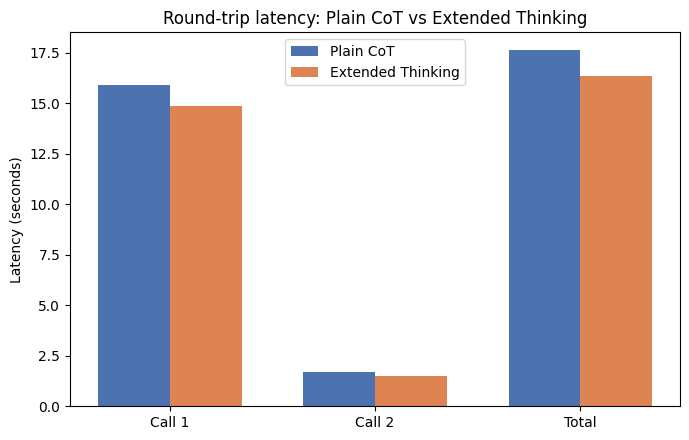

In [17]:
labels_lat = ["Call 1", "Call 2", "Total"]
cot_lat_vals = [
    latency_breakdown["CoT - Call 1"],
    latency_breakdown["CoT - Call 2"],
    cot_total_latency,
]
ext_lat_vals = [
    latency_breakdown["ExtThinking - Call 1"],
    latency_breakdown["ExtThinking - Call 2"],
    ext_total_latency,
]

x4 = range(len(labels_lat))
width4 = 0.35

fig4, ax4 = plt.subplots(figsize=(7, 4.5), facecolor="white")
ax4.set_facecolor("white")
ax4.bar([i - width4 / 2 for i in x4], cot_lat_vals, width4, label="Plain CoT", color="#4C72B0")
ax4.bar([i + width4 / 2 for i in x4], ext_lat_vals, width4, label="Extended Thinking", color="#DD8452")

ax4.set_xticks(list(x4))
ax4.set_xticklabels(labels_lat, color="black")
ax4.set_ylabel("Latency (seconds)", color="black")
ax4.set_title("Round-trip latency: Plain CoT vs Extended Thinking", color="black")
ax4.tick_params(colors="black")
for spine in ax4.spines.values():
    spine.set_color("black")
ax4.legend()
plt.tight_layout()
plt.show()

### Cost vs. latency — the real tradeoff picture

A single scatter plot puts both dimensions side by side. The most
interesting reads for your blog:
- **Bottom-left** (low cost, low latency) is the ideal quadrant.
- If one branch sits **top-right** of the other on both axes, it's strictly
  worse — an easy call.
- If the branches sit in **different quadrants** (e.g. one cheaper but
  slower), that's your genuine tradeoff — the answer becomes "it depends on
  whether your use case is cost-sensitive or latency-sensitive."

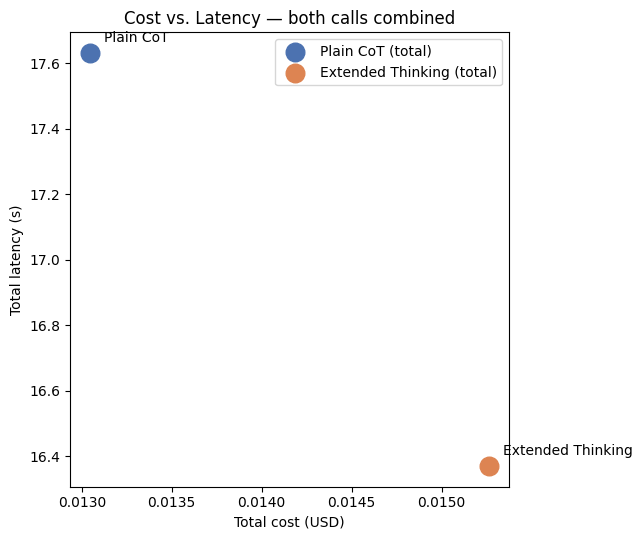

In [18]:
fig5, ax5 = plt.subplots(figsize=(6.5, 5.5), facecolor="white")
ax5.set_facecolor("white")
ax5.scatter([cot_total_cost], [cot_total_latency], s=180, color="#4C72B0", label="Plain CoT (total)")
ax5.scatter([ext_total_cost], [ext_total_latency], s=180, color="#DD8452", label="Extended Thinking (total)")
ax5.annotate("Plain CoT", (cot_total_cost, cot_total_latency), textcoords="offset points", xytext=(10, 8), color="black")
ax5.annotate("Extended Thinking", (ext_total_cost, ext_total_latency), textcoords="offset points", xytext=(10, 8), color="black")
ax5.set_xlabel("Total cost (USD)", color="black")
ax5.set_ylabel("Total latency (s)", color="black")
ax5.set_title("Cost vs. Latency — both calls combined", color="black")
ax5.tick_params(colors="black")
for spine in ax5.spines.values():
    spine.set_color("black")
ax5.legend()
plt.tight_layout()
plt.show()

## Proving the thinking block is integrity-checked

Tamper with a single character inside the returned thinking block and resend.
The docs say this must fail with a `400 invalid_request_error`. Let's confirm it.

In [19]:
import anthropic

tampered_content = copy.deepcopy(ext_call_1.content)
for block in tampered_content:
    if block.type == "thinking":
        block.thinking = block.thinking + " (tampered)"
        break

tampered_messages = [
    {"role": "user", "content": PROBLEM_STATEMENT},
    {"role": "assistant", "content": tampered_content},
    {"role": "user", "content": "Now give me the final decision."},
]

try:
    client.messages.create(
        model=MODEL,
        max_tokens=300,
        thinking={"type": "adaptive"},
        messages=tampered_messages,
    )
    print("No error raised — unexpected.")
except anthropic.BadRequestError as e:
    print("Got the expected 400 error:")
    print(e)

No error raised — unexpected.


## What `redacted_thinking` actually looks like

This uses Anthropic's documented magic test string to *force* a redacted block
on demand — in normal use, redaction is triggered occasionally and automatically
by safety systems, not something you control. This is for illustration only,
to show the block shape, not a technique to rely on in production.

In [20]:
MAGIC_REDACT_STRING = (
    "ANTHROPIC_MAGIC_STRING_TRIGGER_REDACTED_THINKING_46C9A13E193C177646C7398A"
    "98432ECCCE4C1253D5E2D82641AC0E52CC2876CB"
)

redacted_demo = client.messages.create(
    model=MODEL,
    max_tokens=1024,
    thinking={"type": "adaptive"},
    messages=[{"role": "user", "content": MAGIC_REDACT_STRING}],
)

for block in redacted_demo.content:
    print(block.type)

redacted = [b for b in redacted_demo.content if b.type == "redacted_thinking"]
if redacted:
    print("\nredacted_thinking content is opaque/encrypted, e.g.:")
    print(redacted[0].data[:80], "...")
    print(
        "\nThis is NOT a smaller/compressed version of the reasoning — it's the "
        "same reasoning, encrypted. You still pass it back verbatim, same as a "
        "normal thinking block, and Claude decrypts it internally to keep context."
    )
else:
    print("No redacted block this time — try again, behavior can vary by model version.")

redacted_thinking
text

redacted_thinking content is opaque/encrypted, e.g.:
EsEFCpIBCBIYAipABaiL/opJ+JOZ+1t5XCKJd1VdMAlP2VE0KZ/SoiDDpBJtyyoDSFLVpwohQFzVxi9B ...

This is NOT a smaller/compressed version of the reasoning — it's the same reasoning, encrypted. You still pass it back verbatim, same as a normal thinking block, and Claude decrypts it internally to keep context.


# Part 2 — A genuinely hard problem

Part 1's shipment problem is a handful of straightforward comparisons —
easy enough that `effort: "high"` may barely think at all, which is why CoT
could match or beat it there. This section uses a problem that actually
requires careful, multi-step arithmetic across different compounding rules —
the kind of task Anthropic's own guidance points to extended thinking for.

The problem has an objectively checkable numeric answer, so wrong reasoning
shows up as a wrong number, not just a vaguer explanation.

In [23]:
HARD_PROBLEM_STATEMENT = (
    "You have $10,000 to invest, split equally across three accounts "
    "($3,333.33 each):\n"
    "- Account A: 4% annual interest, compounded monthly.\n"
    "- Account B: 3.5% annual interest, compounded quarterly.\n"
    "- Account C: 5% simple annual interest (no compounding).\n\n"
    "After exactly 18 months, you withdraw all the money from whichever "
    "account grew the LEAST in percentage terms, and reinvest 60% of that "
    "withdrawn amount into the account that grew the MOST, keeping the "
    "remaining 40% as cash.\n\n"
    "Calculate, showing your work:\n"
    "1. The balance of each account after 18 months.\n"
    "2. Which account grew the least, and which grew the most (by percentage).\n"
    "3. The exact dollar amount kept as cash.\n"
    "4. The final balance of the account that received the reinvestment "
    "(immediately after reinvestment, no further growth)."
)

print("Hard problem loaded.")

Hard problem loaded.


In [24]:
# --- Branch A (CoT) on the hard problem ---
_t0 = time.time()
hard_cot_call_1 = client.messages.create(
    model=MODEL,
    max_tokens=MAX_TOKENS,
    messages=[
        {
            "role": "user",
            "content": (
                "Think step by step and show your full reasoning before you "
                "answer.\n\n" + HARD_PROBLEM_STATEMENT
            ),
        }
    ],
)
hard_cot_latency = time.time() - _t0
hard_cot_text = "".join(b.text for b in hard_cot_call_1.content if b.type == "text")

print("--- CoT full response ---")
print(hard_cot_text)
print("\nUsage:", hard_cot_call_1.usage)
print(f"Latency: {hard_cot_latency:.2f}s")

--- CoT full response ---
# Step-by-Step Solution

## Step 1: Calculate Balance of Each Account After 18 Months

**Starting principal for each account: $3,333.33**

---

### Account A: 4% annual, compounded monthly

Formula: A = P(1 + r/n)^(nt)

- r = 0.04, n = 12, t = 1.5 years
- nt = 12 × 1.5 = **18 periods**

A = 3,333.33 × (1 + 0.04/12)^18
A = 3,333.33 × (1.003333...)^18

Calculating (1.003333)^18:
- ln(1.003333) ≈ 0.0033278
- 18 × 0.0033278 = 0.059900
- e^0.059900 ≈ 1.061677

**A = 3,333.33 × 1.061677 = $3,538.90**

---

### Account B: 3.5% annual, compounded quarterly

Formula: A = P(1 + r/n)^(nt)

- r = 0.035, n = 4, t = 1.5 years
- nt = 4 × 1.5 = **6 periods**

A = 3,333.33 × (1 + 0.035/4)^6
A = 3,333.33 × (1.00875)^6

Calculating (1.00875)^6:
- ln(1.00875) ≈ 0.0087118
- 6 × 0.0087118 = 0.052271
- e^0.052271 ≈ 1.053662

**B = 3,333.33 × 1.053662 = $3,512.19**

---

### Account C: 5% simple annual interest

Formula: A = P(1 + rt)

- r = 0.05, t = 1.5 years

A = 3,333.33 × (1 + 0

In [25]:
# --- Branch B (Extended Thinking) on the SAME hard problem ---
_t0 = time.time()
hard_ext_call_1 = client.messages.create(
    model=MODEL,
    max_tokens=MAX_TOKENS,
    thinking={"type": "adaptive"},
    output_config={"effort": "high"},
    messages=[{"role": "user", "content": HARD_PROBLEM_STATEMENT}],
)
hard_ext_latency = time.time() - _t0

hard_ext_thinking = [b for b in hard_ext_call_1.content if b.type == "thinking"]
hard_ext_text = "".join(b.text for b in hard_ext_call_1.content if b.type == "text")

if hard_ext_thinking:
    print("--- Extended thinking's internal reasoning (truncated) ---")
    print(hard_ext_thinking[0].thinking[:800], "...\n")
print("--- Extended thinking final answer ---")
print(hard_ext_text)
print("\nUsage:", hard_ext_call_1.usage)
print(f"Latency: {hard_ext_latency:.2f}s")

--- Extended thinking's internal reasoning (truncated) ---
Let me work through this step by step.

**Initial Investment:** $3,333.33 in each of three accounts.

**Account A:** 4% annual interest, compounded monthly
**Account B:** 3.5% annual interest, compounded quarterly
**Account C:** 5% simple annual interest

**Time period:** 18 months = 1.5 years

---

## Step 1: Calculate the balance of each account after 18 months

**Account A: 4% annual, compounded monthly**

Formula: A = P(1 + r/n)^(nt)

Where:
- P = $3,333.33
- r = 0.04, n = 12, t = 1.5, so I need 3333.33 × (1 + 0.04/12)^18. Working through the monthly rate of 0.003333... raised to the 18th power to find the compounded growth factor.

Using natural logs to compute the exponent: ln(1.003333...) ≈ 0.0033306, times 18 gives about 0.05995, and e^0.05995 approximates the growth factor via its ...

--- Extended thinking final answer ---


Usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_toke

In [26]:
# --- Ground truth, computed independently, to check which branch got it right ---
principal = 10000 / 3

balance_a = principal * (1 + 0.04 / 12) ** (12 * 1.5)          # monthly compounding
balance_b = principal * (1 + 0.035 / 4) ** (4 * 1.5)           # quarterly compounding
balance_c = principal * (1 + 0.05 * 1.5)                        # simple interest

growth_a = (balance_a - principal) / principal
growth_b = (balance_b - principal) / principal
growth_c = (balance_c - principal) / principal

accounts = {"A": (balance_a, growth_a), "B": (balance_b, growth_b), "C": (balance_c, growth_c)}
least = min(accounts, key=lambda k: accounts[k][1])
most = max(accounts, key=lambda k: accounts[k][1])

withdrawn = accounts[least][0]
cash_kept = withdrawn * 0.4
reinvested = withdrawn * 0.6
final_balance_most = accounts[most][0] + reinvested

print("--- Ground truth (computed independently in Python) ---")
for name, (bal, growth) in accounts.items():
    print(f"  Account {name}: ${bal:.2f}  ({growth*100:.3f}% growth)")
print(f"\n  Grew least: Account {least}  |  Grew most: Account {most}")
print(f"  Cash kept:            ${cash_kept:.2f}")
print(f"  Final balance ({most}) after reinvestment: ${final_balance_most:.2f}")
print(
    "\nCompare these numbers against both branches' answers above — this is "
    "more informative than cost/latency alone: an approach that's cheaper but "
    "wrong isn't actually cheaper, it's just wrong faster."
)

--- Ground truth (computed independently in Python) ---
  Account A: $3539.10  (6.173% growth)
  Account B: $3512.21  (5.366% growth)
  Account C: $3583.33  (7.500% growth)

  Grew least: Account B  |  Grew most: Account C
  Cash kept:            $1404.88
  Final balance (C) after reinvestment: $5690.66

Compare these numbers against both branches' answers above — this is more informative than cost/latency alone: an approach that's cheaper but wrong isn't actually cheaper, it's just wrong faster.


In [27]:
hard_cot_cost = call_cost_usd(hard_cot_call_1.usage)
hard_ext_cost = call_cost_usd(hard_ext_call_1.usage)

print(f"{'Branch':<20}{'Cost (USD)':>14}{'Latency (s)':>14}")
print("-" * 48)
print(f"{'CoT':<20}{hard_cot_cost:>14.6f}{hard_cot_latency:>14.2f}")
print(f"{'Extended Thinking':<20}{hard_ext_cost:>14.6f}{hard_ext_latency:>14.2f}")
print(
    "\nRead this table ALONGSIDE the ground-truth check above, not instead of "
    "it. On a genuinely hard problem, the interesting comparison isn't just "
    "'which was cheaper' — it's 'which was cheaper AND correct.'"
)

Branch                  Cost (USD)   Latency (s)
------------------------------------------------
CoT                       0.016617         14.25
Extended Thinking         0.031350         24.07

Read this table ALONGSIDE the ground-truth check above, not instead of it. On a genuinely hard problem, the interesting comparison isn't just 'which was cheaper' — it's 'which was cheaper AND correct.'


# Tool-use agentic loop

This is extended thinking's actual design center. Adaptive thinking
automatically enables **interleaved thinking** — Claude can reason *between*
tool calls, deciding what to do next based on what a tool just returned.
Plain CoT has no equivalent: there's no API-level concept of "reasoning
between tool calls" when reasoning is just prompted text.

We give Claude two mock tools for a shipment-routing task and let it call
them in sequence, reasoning in between. Then we show the one case where
preserving thinking blocks is not a best practice but a **hard API
requirement**: stripping thinking blocks out of a tool-use history causes
the request to fail.

In [28]:
tools = [
    {
        "name": "get_fuel_surcharge_rate",
        "description": (
            "Returns the current fuel surcharge percentage carriers apply, "
            "given a route distance in km."
        ),
        "input_schema": {
            "type": "object",
            "properties": {"distance_km": {"type": "number"}},
            "required": ["distance_km"],
        },
    },
    {
        "name": "get_carrier_capacity",
        "description": "Returns the number of available express slots for a named carrier today.",
        "input_schema": {
            "type": "object",
            "properties": {"carrier": {"type": "string"}},
            "required": ["carrier"],
        },
    },
]


def run_mock_tool(name: str, tool_input: dict) -> dict:
    """Fake tool execution — stands in for a real API/DB call."""
    if name == "get_fuel_surcharge_rate":
        distance = tool_input["distance_km"]
        return {"fuel_surcharge_pct": 0.08 if distance > 1500 else 0.05}
    if name == "get_carrier_capacity":
        return {"available_express_slots": 2}
    return {"error": f"unknown tool {name}"}


TOOL_TASK = (
    "A shipment needs to travel 1,850km via carrier 'SwiftFreight'. Look up "
    "the fuel surcharge for this distance and check SwiftFreight's available "
    "express capacity, then recommend whether to book express or standard, "
    "factoring in the surcharge and slot availability."
)

print("Tools and task defined.")

Tools and task defined.


In [29]:
# Run the full agent loop: Claude thinks -> calls a tool -> we execute it ->
# we feed the result back -> Claude thinks again -> calls the next tool ->
# ... until it stops calling tools and gives a final answer.

agent_messages = [{"role": "user", "content": TOOL_TASK}]
total_tool_loop_cost = 0.0
step = 0

while True:
    step += 1
    response = client.messages.create(
        model=MODEL,
        max_tokens=MAX_TOKENS,
        thinking={"type": "adaptive"},
        tools=tools,
        messages=agent_messages,
    )
    total_tool_loop_cost += call_cost_usd(response.usage)

    block_types = [b.type for b in response.content]
    print(f"Step {step}: model returned blocks {block_types}")

    # Echo the assistant turn back verbatim (thinking + tool_use blocks included)
    agent_messages.append({"role": "assistant", "content": response.content})

    if response.stop_reason != "tool_use":
        final_text = "".join(b.text for b in response.content if b.type == "text")
        print("\n--- Final answer ---")
        print(final_text)
        break

    # Execute every tool call the model requested this turn, then send all
    # results back together as a single user turn.
    tool_results = []
    for block in response.content:
        if block.type == "tool_use":
            result = run_mock_tool(block.name, block.input)
            print(f"  -> ran tool '{block.name}'({block.input}) => {result}")
            tool_results.append(
                {
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": json.dumps(result),
                }
            )
    agent_messages.append({"role": "user", "content": tool_results})

print(f"\nTotal agent-loop cost across {step} steps: ${total_tool_loop_cost:.6f}")

Step 1: model returned blocks ['thinking', 'text', 'tool_use', 'tool_use']
  -> ran tool 'get_fuel_surcharge_rate'({'distance_km': 1850}) => {'fuel_surcharge_pct': 0.08}
  -> ran tool 'get_carrier_capacity'({'carrier': 'SwiftFreight'}) => {'available_express_slots': 2}
Step 2: model returned blocks ['text']

--- Final answer ---
Here's a full breakdown and recommendation based on the live data:

---

## 📦 Shipment Analysis — SwiftFreight | 1,850 km

### 🔍 Live Data Retrieved

| Factor | Result |
|---|---|
| 📏 Route Distance | 1,850 km |
| ⛽ Fuel Surcharge Rate | **8%** on base freight cost |
| 🚛 SwiftFreight Express Slots Available Today | **2 slots** |

---

### 💡 Recommendation: **Book Express — But Act Fast!**

Here's the reasoning:

1. **✅ Express Capacity Exists (For Now)**
SwiftFreight has **only 2 express slots remaining** today. That's tight — if there are other shippers in the queue, those slots could disappear quickly. Availability is a real constraint here.

2. **⛽ Fuel Surc

### Why this loop *needed* thinking-block preservation

The loop above worked because every assistant turn — including its thinking
block — was echoed back exactly as received. Now watch what happens if we
rebuild the same history but **drop the thinking blocks**, keeping only the
`tool_use` and `text` blocks. This is a mistake it's easy to make if your
code filters content blocks by type before replaying history.

In [30]:
import anthropic

# Rebuild history from the successful run, but strip thinking/redacted_thinking
# blocks out of every assistant turn.
stripped_messages = []
for msg in agent_messages:
    if msg["role"] == "assistant" and isinstance(msg["content"], list):
        kept = [b for b in msg["content"] if b.type not in ("thinking", "redacted_thinking")]
        stripped_messages.append({"role": "assistant", "content": kept})
    else:
        stripped_messages.append(msg)

try:
    client.messages.create(
        model=MODEL,
        max_tokens=MAX_TOKENS,
        thinking={"type": "adaptive"},
        tools=tools,
        messages=stripped_messages + [{"role": "user", "content": "Confirm your final recommendation."}],
    )
    print("No error — unexpected. (Behavior can vary; some models/turns tolerate this differently.)")
except anthropic.BadRequestError as e:
    print("Got the expected 400 error from dropping thinking blocks in a tool-use history:")
    print(e)
    print(
        "\nThis is the concrete difference from CoT: plain CoT text has no such "
        "protection, so a similar mistake (silently dropping or editing part of "
        "a pasted-back reasoning transcript) would NOT error — it would just "
        "quietly produce a worse or inconsistent answer with no warning."
    )

No error — unexpected. (Behavior can vary; some models/turns tolerate this differently.)


## Takeaways for the article

1. **Mechanism, not magic**: Plain CoT reasoning is ordinary text you own and must manually re-paste into every subsequent call. Extended thinking reasoning comes back as a structured, signed block that you echo back verbatim — the API validates it and decides internally which parts still matter.
2. **`redacted_thinking` ≠ "lite" thinking.** It's an *encrypted*, occasional safety fallback — same reasoning, not a cheaper one. Don't build a cost argument around it.
3. **Where the real savings come from**: the API bills input tokens only for the thinking blocks it actually still needs across turns, and this is per-model and automatic. On a single 2-call round trip the gap may be small; it's a multi-turn, multi-tool-call agent loop where this compounds.
4. **Integrity, not convenience**: thinking blocks are tamper-evident (`signature` field). Edit one character and the whole request 400s. CoT text has no such protection — you could silently corrupt your own reasoning trail and the API would never know.
5. **Best real-world fit**: agentic tool-use loops, where the docs make preserving thinking blocks a hard requirement rather than a style choice — that's the strongest, most defensible example for your article.
6. **Cost, not just tokens, is the fair unit of comparison.** Thinking tokens are billed as *output* (the expensive side), so a token-count chart alone can be misleading — convert both branches to USD before claiming one is "cheaper." On a short 2-call exchange the dollar gap may be small or even favor CoT; the multi-turn simulation is what actually shows the cost curves diverging, which is the more honest number to lead your blog with.
7. **Cost and latency can pull in different directions.** Extended thinking reasons before its first visible token, which tends to push up round-trip latency even when it's cheaper on tokens/cost. Don't present this as a strictly-better-or-worse comparison — the cost-vs-latency scatter plot is the honest way to show "it depends on whether your use case is cost-sensitive or latency-sensitive."
8. **On an easy problem, CoT can legitimately win on every metric.** Part 1's shipment decision is simple enough that adaptive thinking may barely engage — that's not a bug in the test, it's the correct behavior of "adaptive." This is worth stating plainly in the article rather than hiding it: extended thinking isn't a universal upgrade, it's a tool for a specific class of problem.
9. **Correctness, not just cost, is the real test on hard problems.** Part 2 pairs each branch's answer against an independently-computed ground truth. A cheaper wrong answer isn't actually cheaper — it's wrong faster. This is the strongest argument for extended thinking: not lower cost, but a higher likelihood of getting genuinely hard, multi-step problems right.
10. **Interleaved thinking in tool-use loops is extended thinking's real design target.** Part 3 shows the mechanism CoT structurally cannot replicate: reasoning *between* tool calls, automatically enabled by adaptive mode. And unlike a CoT transcript — where silently dropping or editing part of the pasted-back reasoning would fail silently — dropping thinking blocks from a tool-use history throws a hard, visible error. That's the difference between a convention you have to remember to follow and a contract the API enforces for you.